In [14]:
from TM_SI import fixed_tuning_TM_SI_randj
from practical_transmission import noise_score_references
import matplotlib.pyplot as plt
import numpy as np
from scipy import stats

In [15]:
p, nt, ns, K = 100, 30, 50, 2
sigma = 1.0
quantile = 0.35
n_rep = 1000

In [16]:
rng = np.random.default_rng()

X0 = rng.standard_normal((nt, p))
X_list = [rng.standard_normal((ns, p)) for _ in range(K)]

Sigma_0 = sigma ** 2 * np.eye(nt)
Sigma_K = [sigma ** 2 * np.eye(ns) for _ in range(K)]

lambda_0, lambda_T = noise_score_references(
    X0, X_list, sigma=sigma, quantile=quantile,
    n_draws=5000, batch_size=250, seed=None,
)
print(f'lambda_0 = {lambda_0:.5f}   lambda_T = {lambda_T:.5f}')

lambda_0 = 0.22633   lambda_T = 0.46032


In [29]:
def run(n_rep):
    p_values, branches, n_empty = [], [], 0

    for i in range(1, n_rep + 1):
        y0 = sigma * rng.standard_normal(nt)
        y_list = [sigma * rng.standard_normal(ns) for _ in range(K)]

        result = fixed_tuning_TM_SI_randj(
            X0, y0, X_list, y_list, lambda_0, lambda_T,
            Sigma_0, Sigma_K, rng=rng,
        )

        if result['results']:
            p_values.append(result['results'][0]['p_value'])
            branches.append(result['branch'])
        else:
            n_empty += 1

        if i % 50 == 0:
            print(f"{i}/{n_rep}, "
                  f"p-values: {len(p_values)}, "
                  f"empty models: {n_empty}",)

    return np.array(p_values), branches, n_empty

In [39]:
list_p_value, _, _ = run(n_rep)

50/1000, p-values: 32, empty models: 18
100/1000, p-values: 55, empty models: 45
150/1000, p-values: 91, empty models: 59
200/1000, p-values: 123, empty models: 77
250/1000, p-values: 158, empty models: 92
300/1000, p-values: 196, empty models: 104
350/1000, p-values: 228, empty models: 122
400/1000, p-values: 258, empty models: 142
450/1000, p-values: 290, empty models: 160
500/1000, p-values: 323, empty models: 177
550/1000, p-values: 359, empty models: 191
600/1000, p-values: 392, empty models: 208
650/1000, p-values: 427, empty models: 223
700/1000, p-values: 461, empty models: 239
750/1000, p-values: 497, empty models: 253
800/1000, p-values: 523, empty models: 277
850/1000, p-values: 556, empty models: 294
900/1000, p-values: 590, empty models: 310
950/1000, p-values: 622, empty models: 328
1000/1000, p-values: 649, empty models: 351


In [40]:
alpha = 0.05
FPR = np.mean(list_p_value <= alpha)
print(f"FPR = {FPR}")

FPR = 0.04160246533127889


In [41]:
statistic, p_value = stats.kstest(list_p_value, 'uniform')
print(f'KS-Test statistic = {statistic}')
print(f'KS-Test p-value = {p_value}')

KS-Test statistic = 0.035175752092345164
KS-Test p-value = 0.3891521805098702


(array([27., 30., 37., 25., 25., 43., 41., 27., 35., 30., 24., 29., 30.,
        40., 29., 37., 40., 36., 34., 30.]),
 array([9.13661880e-05, 5.00466003e-02, 1.00001834e-01, 1.49957068e-01,
        1.99912303e-01, 2.49867537e-01, 2.99822771e-01, 3.49778005e-01,
        3.99733239e-01, 4.49688473e-01, 4.99643707e-01, 5.49598941e-01,
        5.99554175e-01, 6.49509409e-01, 6.99464644e-01, 7.49419878e-01,
        7.99375112e-01, 8.49330346e-01, 8.99285580e-01, 9.49240814e-01,
        9.99196048e-01]),
 <BarContainer object of 20 artists>)

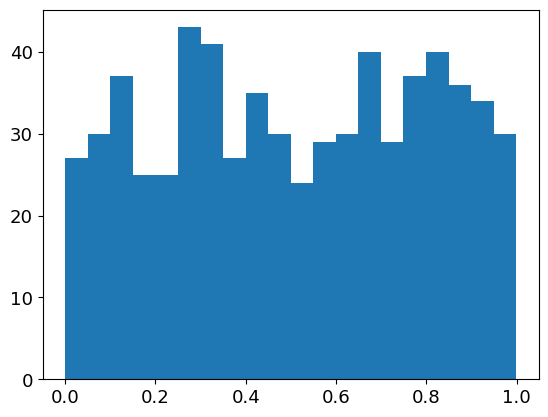

In [42]:
plt.hist(list_p_value, bins=20)